# House Price Prediction

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Dataset Preview:
   Area_sqft  Bedrooms  Bathrooms  House_Age   Price
0       1360         3          1         20  118932
1       1794         2          3         15  137869
2       1630         3          1         21  103241
3       1595         3          2         20  116138
4       2138         4          2         10  146469

Model Performance:
Mean Absolute Error : 8868.062487419322
Mean Squared Error  : 110022377.88845494
Root MSE            : 10489.155251423012
R2 Score            : 0.9203996441516286


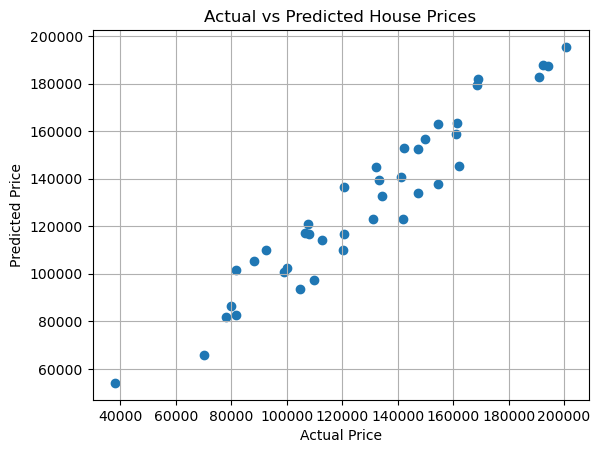

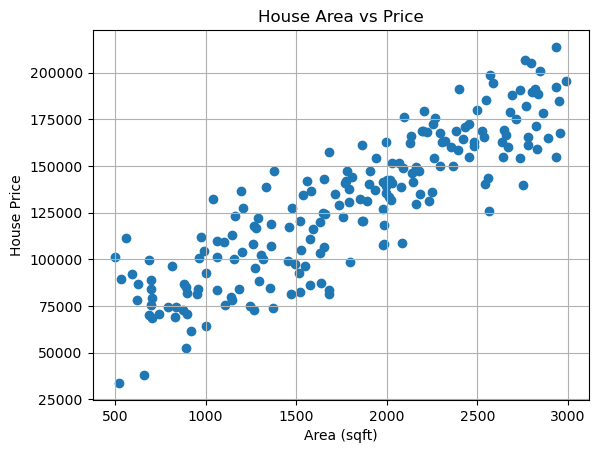


Predicted Price for Sample House: 133219.91620529577


In [5]:
df = pd.read_csv("house_data.csv")
print("Dataset Preview:")
print(df.head())

X = df[["Area_sqft", "Bedrooms", "Bathrooms", "House_Age"]]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root MSE            :", rmse)
print("R2 Score            :", r2)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df["Area_sqft"], df["Price"])
plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("House Area vs Price")
plt.grid(True)
plt.show()

sample_house = pd.DataFrame({
    "Area_sqft": [1800],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "House_Age": [5]
})

predicted_price = model.predict(sample_house)
print("\nPredicted Price for Sample House:", predicted_price[0])